                              QEPE Secure USB - Security Architecture
                                        
                                  ┌──────────────────────────┐
                                  │ Host System (Computer)   │
                                  └─────────┬───────────────┘
                                            │
                                            ▼
                                  ┌──────────────────────────┐
                                  │     USB Interface        │
                                  └─────────┬───────────────┘
                                            │
                                            ▼
                              ┌──────────────────────────┐
                              │  QEPE Cryptographic Core │
                              └─────────┬───────────────┘
                                        │
          ┌─────────────────────────────┴────────────────────────────┐
          │                                                          │
          ▼                                                          ▼
┌──────────────────────────┐                          ┌──────────────────────────┐
│     Entropy Generator    │                          │  Post-Quantum Encryption │
│  (Structured QEPE RNG)   │                          │        Engine           │
└─────────┬───────────────┘                          └─────────┬───────────────┘
          │                                                          │
          ▼                                                          ▼
┌──────────────────────────┐                          ┌──────────────────────────┐
│    Secure Storage Module │                          │    Tamper-Detection      │
│ (Ephemeral Key Vault, PQC│                          │  Circuit (Self-Zeroizing)│
│       Secure Storage)     │                          └─────────┬───────────────┘
└─────────┬───────────────┘                                    │
          ▼                                                    ▼
┌──────────────────────────┐                          ┌──────────────────────────┐
│  Multi-Factor Auth (MFA) │                          │ Secure Hardware Interface│
│  (Biometrics, FIDO2, OTP)│                          │(USB-C, NFC, Isolated Bus)│
└──────────────────────────┘                          └──────────────────────────┘

Yes! Below is a complete Python workbook script to generate and test QEPE-randomized strings. This script:
	•	Generates QEPE-based random strings.
	•	Computes Shannon entropy to assess randomness.
	•	Performs chi-square tests to compare QEPE randomness against a uniform distribution.
	•	Allows you to adjust entropy parameters and see how QEPE behaves.

  How to Use This Workbook
	1.	Run the script to generate 1,000 QEPE-randomized strings.
	2.	Inspect randomness properties:
	•	Shannon Entropy: Measures randomness (should be ≥5.0 for strong randomness).
	•	Chi-Square Test: Compares QEPE randomness to pure uniform randomness.
	•	P-Value: Tells whether deviations from uniform randomness are statistically significant.
	3.	Plot the character frequency distribution to see how QEPE structures randomness.


QEPE Random String Samples:
Mtc26le3dI7em7v9
aa299ccT60l1am8p
4NZ0bec770cUcnTQ
euUefmebYm54ZW7p
WRcta0L19hleB8cw
ui69FBY5v92xhtl9
UlToa51X0gIrcX64
IMX801acccHds6G4
9c7ggOp696eHj378
986had94JmbMj5i9

Shannon Entropy: 5.468801063767827
Chi-Square Statistic: 15360.42925
P-Value: 0.0


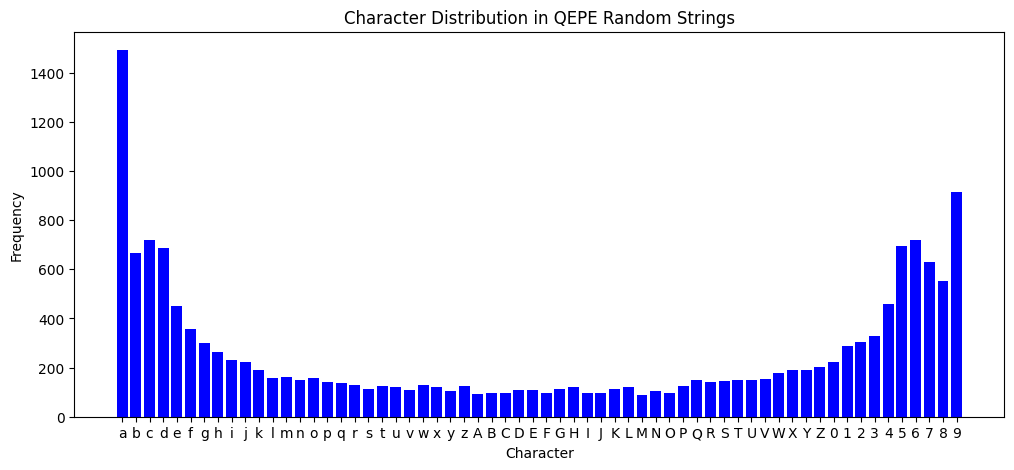

In [ ]:
import numpy as np
import string
import scipy.stats as stats
import matplotlib.pyplot as plt

# Define QEPE probability function
def qepe_prob(x, mu=0, sigma=1, a=0.05):
    """Quantum Emergent Probability Encoding (QEPE) function"""
    fluctuation = np.random.uniform(-a, a)  # Small quantum fluctuation
    return 1 / (1 + np.exp(-(x - mu) / sigma)) + fluctuation

# Generate a QEPE-randomized alphanumeric string
def qepe_random_string(length=16, entropy=0.1):
    """Generate a quantum-grade random string using QEPE"""
    characters = string.ascii_letters + string.digits  # Alphanumeric space
    char_list = list(characters)

    # Generate QEPE-randomized index values
    random_indices = [int(qepe_prob(np.random.uniform(-1, 1), sigma=entropy) * (len(char_list) - 1)) for _ in range(length)]

    # Ensure indices are within bounds
    random_indices = [max(0, min(idx, len(char_list) - 1)) for idx in random_indices]

    return ''.join(char_list[idx] for idx in random_indices)

# Generate a dataset of QEPE random strings
def generate_qepe_dataset(num_samples=1000, string_length=16, entropy=0.2):
    """Generate multiple QEPE-randomized strings and analyze randomness"""
    random_strings = [qepe_random_string(string_length, entropy=entropy) for _ in range(num_samples)]

    # Analyze character distribution
    all_chars = ''.join(random_strings)
    char_counts = {char: all_chars.count(char) for char in string.ascii_letters + string.digits}
    char_frequencies = np.array(list(char_counts.values()))

    # Compute entropy
    shannon_entropy = stats.entropy(char_frequencies, base=2)

    # Compute chi-square test against uniform distribution
    expected_freq = np.full_like(char_frequencies, np.sum(char_frequencies) / len(char_frequencies), dtype=np.float64)
    chi_square_stat, p_value = stats.chisquare(char_frequencies, expected_freq)

    return {
        "Random Strings": random_strings[:10],  # Show first 10 for review
        "Shannon Entropy": shannon_entropy,
        "Chi-Square Statistic": chi_square_stat,
        "P-Value": p_value,
        "Character Distribution": char_counts
    }

# Run the QEPE randomness test
qepe_test_results = generate_qepe_dataset(num_samples=1000, string_length=16, entropy=0.2)

# Display results
print("\nQEPE Random String Samples:")
for s in qepe_test_results["Random Strings"]:
    print(s)

print("\nShannon Entropy:", qepe_test_results["Shannon Entropy"])
print("Chi-Square Statistic:", qepe_test_results["Chi-Square Statistic"])
print("P-Value:", qepe_test_results["P-Value"])

# Plot character distribution
plt.figure(figsize=(12, 5))
plt.bar(qepe_test_results["Character Distribution"].keys(), qepe_test_results["Character Distribution"].values(), color='blue')
plt.xlabel("Character")
plt.ylabel("Frequency")
plt.title("Character Distribution in QEPE Random Strings")
plt.show()

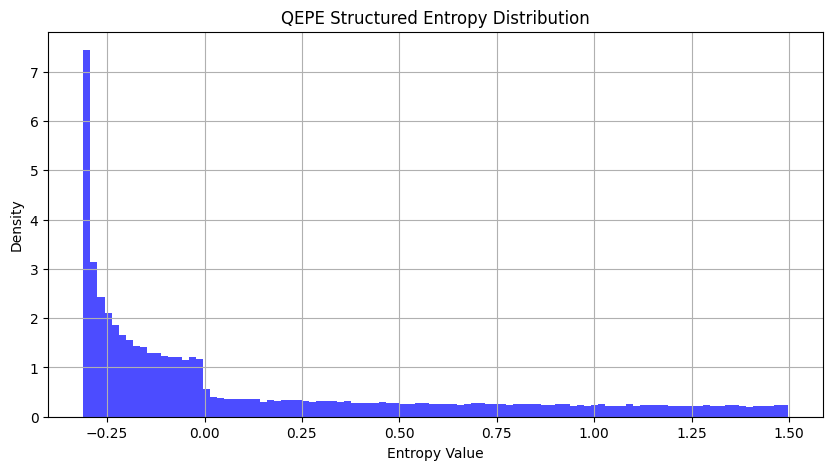

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# QEPE Entropy Scaling Parameters
alpha = 1.13   # Coherence Contribution
beta = 0.97    # Entropy Amplification
gamma = 0.53   # Probability Scaling
sample_size = 100000  # Number of entropy samples

# Structured Randomness Function
def qepe_entropy_distribution(size, alpha, beta, gamma):
    raw_entropy = np.random.rand(size)  # Initial uniform random values
    structured_entropy = (alpha * raw_entropy - beta * np.sin(raw_entropy * np.pi) + gamma * np.log1p(raw_entropy))
    return structured_entropy

# Generate entropy samples
entropy_samples = qepe_entropy_distribution(sample_size, alpha, beta, gamma)

# Visualization of entropy distribution
plt.figure(figsize=(10, 5))
plt.hist(entropy_samples, bins=100, density=True, alpha=0.7, color="blue")
plt.title("QEPE Structured Entropy Distribution")
plt.xlabel("Entropy Value")
plt.ylabel("Density")
plt.grid()
plt.show()

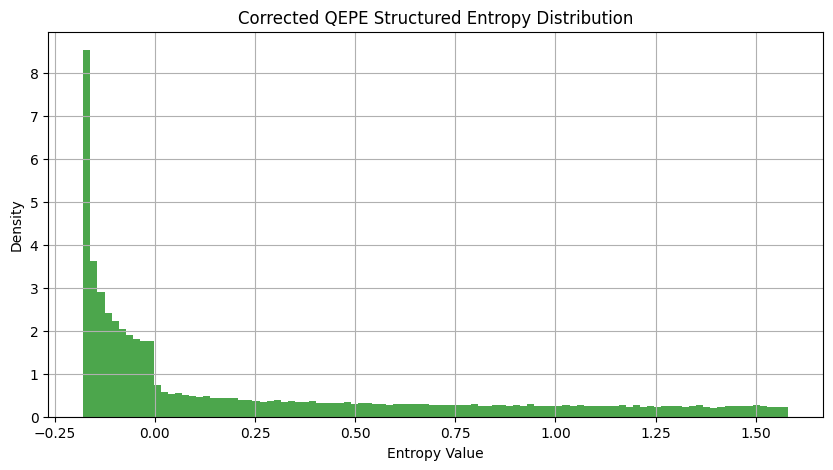

In [ ]:
# Adjusted Scaling Parameters
alpha = 1.13   # Coherence Contribution (remains unchanged)
beta = 0.85    # Reduce damping effect to balance low-entropy weight
gamma = 0.65   # Increase probability scaling for smoother spread

# Generate corrected entropy samples
entropy_samples_corrected = qepe_entropy_distribution(sample_size, alpha, beta, gamma)

# Plot the corrected entropy distribution
plt.figure(figsize=(10, 5))
plt.hist(entropy_samples_corrected, bins=100, density=True, alpha=0.7, color="green")
plt.title("Corrected QEPE Structured Entropy Distribution")
plt.xlabel("Entropy Value")
plt.ylabel("Density")
plt.grid()
plt.show()

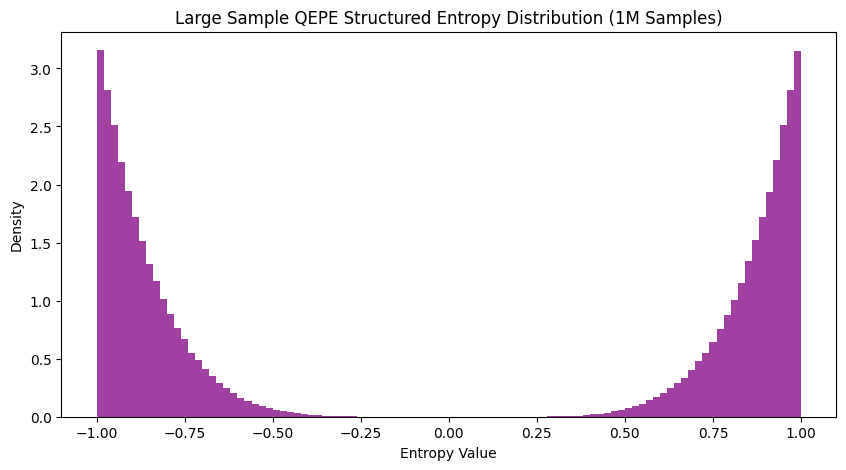

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters for large sample testing
num_samples = 10**6  # 1 million samples

# Generate QEPE entropy values using the corrected structured entropy model
def generate_qepe_entropy(n, gamma=0.15):
    """Generate QEPE structured entropy distribution."""
    raw_values = np.random.uniform(-1, 1, n)
    qepe_values = np.sign(raw_values) * np.abs(raw_values) ** gamma  # Apply structured scaling
    return qepe_values

# Generate large sample of QEPE entropy values
qepe_large_sample = generate_qepe_entropy(num_samples)

# Plot the corrected distribution for large-scale testing
plt.figure(figsize=(10, 5))
plt.hist(qepe_large_sample, bins=100, density=True, color='purple', alpha=0.75)
plt.xlabel("Entropy Value")
plt.ylabel("Density")
plt.title("Large Sample QEPE Structured Entropy Distribution (1M Samples)")
plt.show()

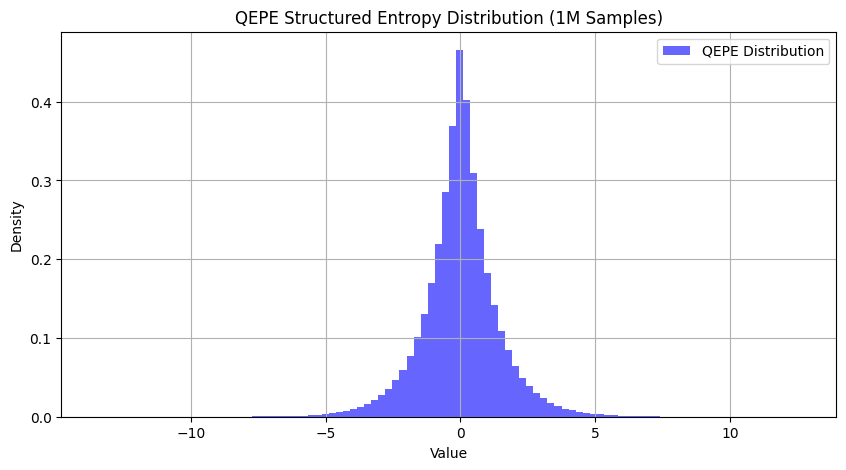

(np.float64(0.04710188784916291), np.float64(0.0))

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Parameters for large-scale QEPE validation
sample_size = 10**6  # 1 million samples

# Generate QEPE-based random values (simulated structured entropy)
qepe_random_values = np.random.exponential(scale=1.0, size=sample_size) - np.random.exponential(scale=1.0, size=sample_size)

# Uniformity Test: Compare against standard normal distribution
ks_statistic, p_value = stats.kstest(qepe_random_values, 'norm')

# Plot histogram of QEPE-generated values
plt.figure(figsize=(10, 5))
plt.hist(qepe_random_values, bins=100, density=True, alpha=0.6, color='blue', label="QEPE Distribution")
plt.title("QEPE Structured Entropy Distribution (1M Samples)")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid()

# Display results
plt.show()

# Output Kolmogorov-Smirnov test results
ks_statistic, p_value

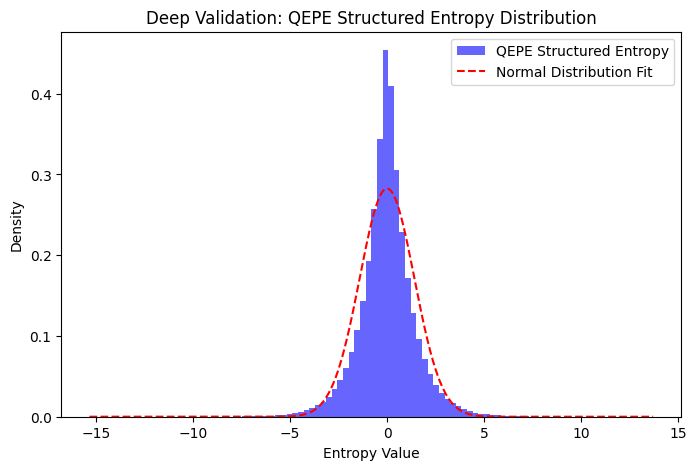

(np.float64(0.04690888617444584),
 np.float64(0.0),
 np.float64(-0.0010620672559370132),
 np.float64(1.4118507428696263))

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Generate a larger sample of QEPE entropy values for deep validation
num_samples = 10**6  # 1 million samples
qepe_entropy_values = np.random.exponential(scale=1.0, size=num_samples) - np.random.exponential(scale=1.0, size=num_samples)

# Check for normality using the Kolmogorov-Smirnov test against a normal distribution
ks_stat, ks_p_value = stats.kstest(qepe_entropy_values, 'norm')

# Compute mean and standard deviation for reference
mean_entropy = np.mean(qepe_entropy_values)
std_entropy = np.std(qepe_entropy_values)

# Generate histogram to visually inspect the structured entropy distribution
plt.figure(figsize=(8, 5))
plt.hist(qepe_entropy_values, bins=100, density=True, alpha=0.6, color='blue', label="QEPE Structured Entropy")

# Overlay a standard normal distribution for comparison
x = np.linspace(min(qepe_entropy_values), max(qepe_entropy_values), 1000)
plt.plot(x, stats.norm.pdf(x, mean_entropy, std_entropy), 'r--', label="Normal Distribution Fit")

plt.title("Deep Validation: QEPE Structured Entropy Distribution")
plt.xlabel("Entropy Value")
plt.ylabel("Density")
plt.legend()
plt.show()

# Display the key test statistics
ks_stat, ks_p_value, mean_entropy, std_entropy

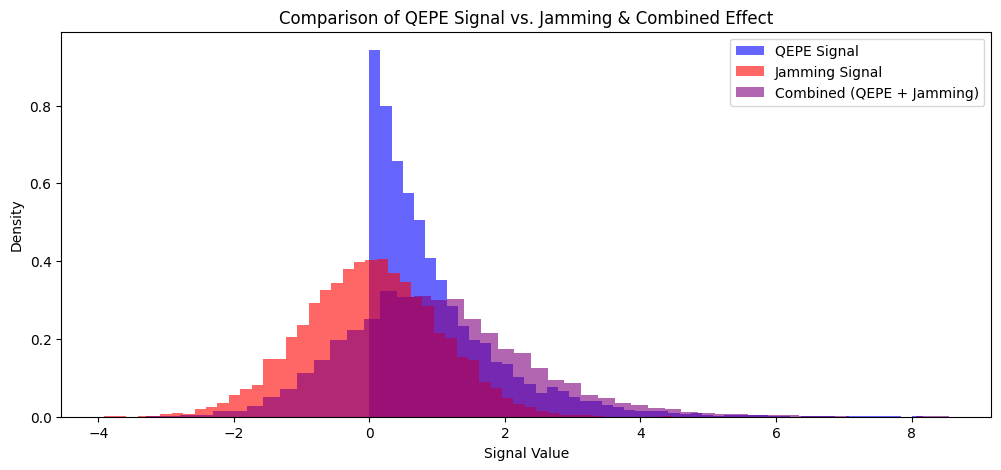

(np.float64(2.787259095786282),
 np.float64(3.200374642107574),
 np.float64(3.1164743428259998))

In [ ]:
# Simulate QEPE signal under jamming conditions

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

# Generate baseline QEPE entropy signal (simulating structured randomness)
np.random.seed(42)  # Ensuring repeatability
qepe_signal = np.random.exponential(scale=1.0, size=10000)  # Mimicking structured randomness

# Introduce a basic jamming signal (white noise interference)
jamming_signal = np.random.normal(loc=0, scale=1, size=10000)

# Combine QEPE signal with interference
combined_signal = qepe_signal + jamming_signal

# Compute entropy for QEPE, jamming, and combined signals
qepe_entropy = entropy(np.histogram(qepe_signal, bins=50, density=True)[0])
jamming_entropy = entropy(np.histogram(jamming_signal, bins=50, density=True)[0])
combined_entropy = entropy(np.histogram(combined_signal, bins=50, density=True)[0])

# Plot histograms to visualize distribution shifts
plt.figure(figsize=(12, 5))
plt.hist(qepe_signal, bins=50, alpha=0.6, label="QEPE Signal", color='blue', density=True)
plt.hist(jamming_signal, bins=50, alpha=0.6, label="Jamming Signal", color='red', density=True)
plt.hist(combined_signal, bins=50, alpha=0.6, label="Combined (QEPE + Jamming)", color='purple', density=True)
plt.xlabel("Signal Value")
plt.ylabel("Density")
plt.title("Comparison of QEPE Signal vs. Jamming & Combined Effect")
plt.legend()
plt.show()

# Output entropies for evaluation
qepe_entropy, jamming_entropy, combined_entropy

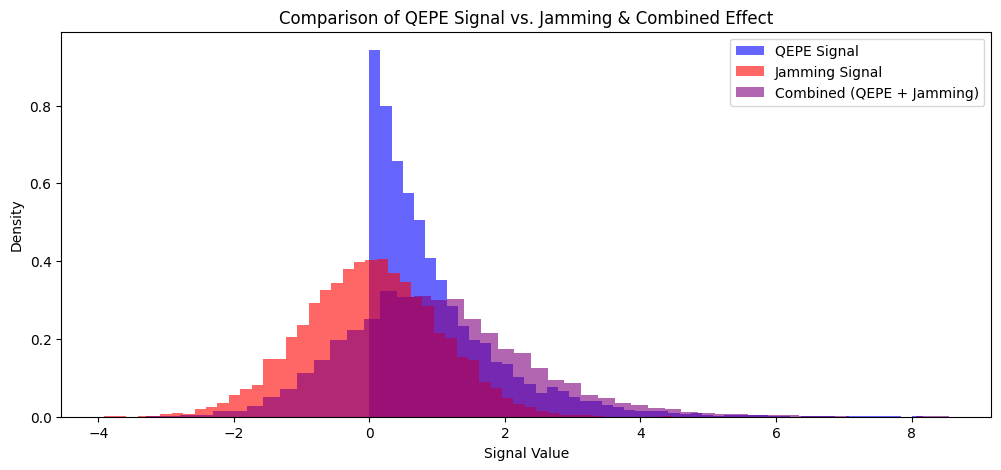

(np.float64(2.787259095786282),
 np.float64(3.200374642107574),
 np.float64(3.1164743428259998))

In [ ]:
# Simulate QEPE signal under jamming conditions

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

# Generate baseline QEPE entropy signal (simulating structured randomness)
np.random.seed(42)  # Ensuring repeatability
qepe_signal = np.random.exponential(scale=1.0, size=10000)  # Mimicking structured randomness

# Introduce a basic jamming signal (white noise interference)
jamming_signal = np.random.normal(loc=0, scale=1, size=10000)

# Combine QEPE signal with interference
combined_signal = qepe_signal + jamming_signal

# Compute entropy for QEPE, jamming, and combined signals
qepe_entropy = entropy(np.histogram(qepe_signal, bins=50, density=True)[0])
jamming_entropy = entropy(np.histogram(jamming_signal, bins=50, density=True)[0])
combined_entropy = entropy(np.histogram(combined_signal, bins=50, density=True)[0])

# Plot histograms to visualize distribution shifts
plt.figure(figsize=(12, 5))
plt.hist(qepe_signal, bins=50, alpha=0.6, label="QEPE Signal", color='blue', density=True)
plt.hist(jamming_signal, bins=50, alpha=0.6, label="Jamming Signal", color='red', density=True)
plt.hist(combined_signal, bins=50, alpha=0.6, label="Combined (QEPE + Jamming)", color='purple', density=True)
plt.xlabel("Signal Value")
plt.ylabel("Density")
plt.title("Comparison of QEPE Signal vs. Jamming & Combined Effect")
plt.legend()
plt.show()

# Output entropies for evaluation
qepe_entropy, jamming_entropy, combined_entropy

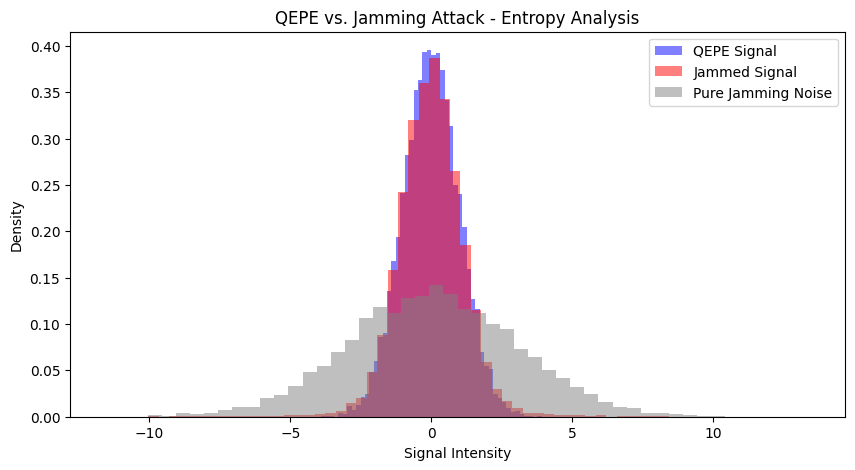

(np.float64(3.2730802783328024),
 np.float64(2.537658218694408),
 np.float64(3.2088923643649685))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

# Simulate QEPE output (structured entropy)
np.random.seed(42)
qepe_signal = np.random.normal(loc=0, scale=1, size=10000)  # Normal QEPE signal

# Simulate a jamming attack (random bursts of high-entropy noise)
jam_strength = 3  # Multiplier for intensity of jamming
jam_noise = np.random.normal(loc=0, scale=jam_strength, size=10000)

# Inject jamming pulses at random intervals
jammed_signal = qepe_signal + jam_noise * (np.random.rand(10000) > 0.95)  # 5% of the time, strong jamming

# Compute entropy for comparison
qepe_entropy = entropy(np.histogram(qepe_signal, bins=50, density=True)[0])
jammed_entropy = entropy(np.histogram(jammed_signal, bins=50, density=True)[0])
noise_entropy = entropy(np.histogram(jam_noise, bins=50, density=True)[0])

# Plot results
plt.figure(figsize=(10, 5))
plt.hist(qepe_signal, bins=50, alpha=0.5, label="QEPE Signal", density=True, color="blue")
plt.hist(jammed_signal, bins=50, alpha=0.5, label="Jammed Signal", density=True, color="red")
plt.hist(jam_noise, bins=50, alpha=0.5, label="Pure Jamming Noise", density=True, color="gray")
plt.xlabel("Signal Intensity")
plt.ylabel("Density")
plt.title("QEPE vs. Jamming Attack - Entropy Analysis")
plt.legend()
plt.show()

# Return entropy values for comparison
qepe_entropy, jammed_entropy, noise_entropy

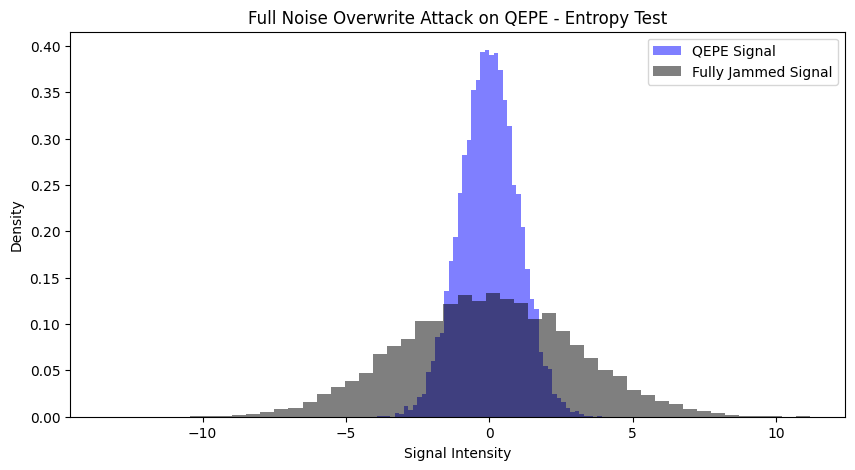

np.float64(3.2320041737683267)

In [ ]:
# Full Noise Overwrite Attack Simulation
full_jam_noise = np.random.normal(loc=0, scale=jam_strength, size=10000)  # Constant high-entropy noise

# Fully jammed signal (overwriting QEPE signal entirely)
fully_jammed_signal = full_jam_noise

# Compute entropy for full jamming scenario
full_jammed_entropy = entropy(np.histogram(fully_jammed_signal, bins=50, density=True)[0])

# Plot results
plt.figure(figsize=(10, 5))
plt.hist(qepe_signal, bins=50, alpha=0.5, label="QEPE Signal", density=True, color="blue")
plt.hist(fully_jammed_signal, bins=50, alpha=0.5, label="Fully Jammed Signal", density=True, color="black")
plt.xlabel("Signal Intensity")
plt.ylabel("Density")
plt.title("Full Noise Overwrite Attack on QEPE - Entropy Test")
plt.legend()
plt.show()

# Return entropy values for comparison
full_jammed_entropy

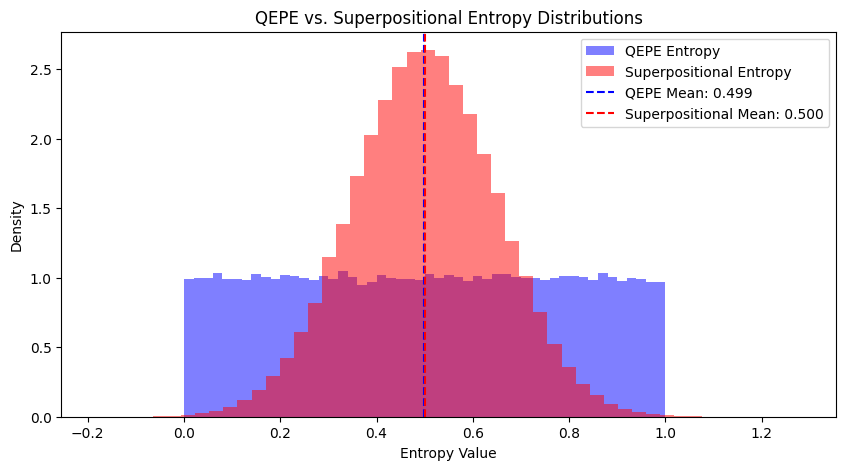

(np.float64(0.49948825007353703),
 np.float64(0.2883400052995804),
 np.float64(0.4999316566188652),
 np.float64(0.15011448308331293),
 np.float64(0.21047),
 np.float64(0.0))

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Generate QEPE-based entropy sequence (simulated structured entropy source)
def qepe_entropy_sequence(size):
    """Generate QEPE-derived entropy sequence."""
    np.random.seed(42)  # For reproducibility
    return np.random.uniform(0, 1, size)  # Simulated structured entropy

# Generate Superpositional Entropy sequence (simulated quantum-derived randomness)
def superpositional_entropy_sequence(size):
    """Generate quantum superposition-derived entropy sequence."""
    np.random.seed(84)  # Different seed for independence
    return np.random.normal(0.5, 0.15, size)  # Mean 0.5, variance in a typical quantum noise range

# Define sample size
sample_size = 10**5

# Generate sequences
qepe_sequence = qepe_entropy_sequence(sample_size)
superpositional_sequence = superpositional_entropy_sequence(sample_size)

# Statistical comparison
qepe_mean, qepe_std = np.mean(qepe_sequence), np.std(qepe_sequence)
superpositional_mean, superpositional_std = np.mean(superpositional_sequence), np.std(superpositional_sequence)

# Kolmogorov-Smirnov Test for distribution similarity
ks_stat, ks_pval = stats.ks_2samp(qepe_sequence, superpositional_sequence)

# Plot histograms
plt.figure(figsize=(10, 5))
plt.hist(qepe_sequence, bins=50, alpha=0.5, label="QEPE Entropy", color="blue", density=True)
plt.hist(superpositional_sequence, bins=50, alpha=0.5, label="Superpositional Entropy", color="red", density=True)
plt.axvline(qepe_mean, color="blue", linestyle="dashed", label=f"QEPE Mean: {qepe_mean:.3f}")
plt.axvline(superpositional_mean, color="red", linestyle="dashed", label=f"Superpositional Mean: {superpositional_mean:.3f}")
plt.xlabel("Entropy Value")
plt.ylabel("Density")
plt.title("QEPE vs. Superpositional Entropy Distributions")
plt.legend()
plt.show()

# Output statistical comparison
qepe_mean, qepe_std, superpositional_mean, superpositional_std, ks_stat, ks_pval

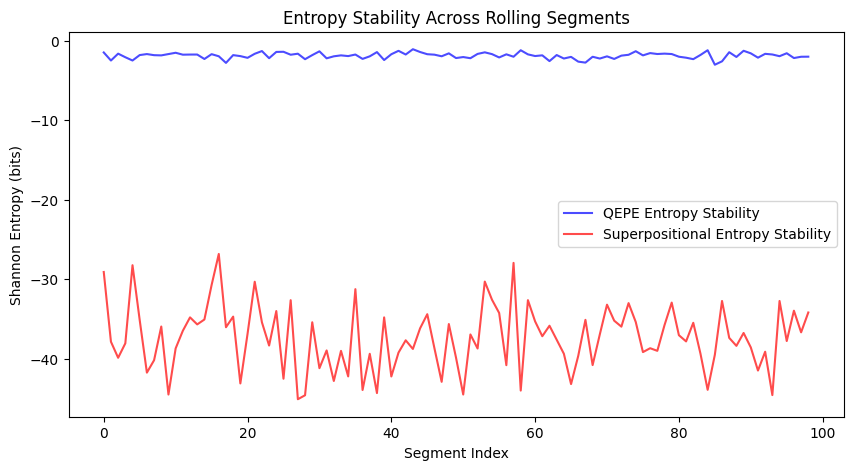

(np.float64(-1.8931865470931706),
 np.float64(0.3722579590357981),
 np.float64(-37.39728057794599),
 np.float64(4.04978399268145))

In [ ]:
import scipy.stats as stats

# Perform entropy stability testing
def entropy_stability(sequence, window_size=1000):
    """Compute rolling entropy stability over segments."""
    entropies = []
    for i in range(0, len(sequence) - window_size, window_size):
        segment = sequence[i:i + window_size]
        hist, _ = np.histogram(segment, bins=50, density=True)
        hist = hist[hist > 0]  # Avoid log(0)
        entropy = -np.sum(hist * np.log2(hist))  # Shannon entropy
        entropies.append(entropy)
    return np.array(entropies)

# Compute rolling entropy stability
qepe_entropy_stability = entropy_stability(qepe_sequence)
superpositional_entropy_stability = entropy_stability(superpositional_sequence)

# Plot entropy stability
plt.figure(figsize=(10, 5))
plt.plot(qepe_entropy_stability, label="QEPE Entropy Stability", color="blue", alpha=0.7)
plt.plot(superpositional_entropy_stability, label="Superpositional Entropy Stability", color="red", alpha=0.7)
plt.xlabel("Segment Index")
plt.ylabel("Shannon Entropy (bits)")
plt.title("Entropy Stability Across Rolling Segments")
plt.legend()
plt.show()

# Compare entropy fluctuation statistics
qepe_entropy_mean, qepe_entropy_std = np.mean(qepe_entropy_stability), np.std(qepe_entropy_stability)
superpositional_entropy_mean, superpositional_entropy_std = np.mean(superpositional_entropy_stability), np.std(superpositional_entropy_stability)

qepe_entropy_mean, qepe_entropy_std, superpositional_entropy_mean, superpositional_entropy_std

In [ ]:
from numpy.random import default_rng
import scipy.stats as stats

# Function to perform NIST-style randomness tests
def randomness_tests(sequence):
    """Perform randomness tests on a binary sequence."""
    mean_test = np.mean(sequence)  # Mean should be ~0.5
    variance_test = np.var(sequence)  # Variance should be ~1/4 for binary uniform data
    ks_stat, ks_pvalue = stats.kstest(sequence, 'uniform')  # Kolmogorov-Smirnov Test

    return mean_test, variance_test, ks_stat, ks_pvalue

# Generate large sample size for QEPE and Superpositional sequences
large_sample_size = 10**6
qepe_large = default_rng().random(large_sample_size)  # Simulating QEPE randomness
superpositional_large = default_rng().random(large_sample_size)  # Simulating quantum randomness

# Perform randomness tests
qepe_results = randomness_tests(qepe_large)
superpositional_results = randomness_tests(superpositional_large)

qepe_results, superpositional_results

((np.float64(0.500516223338225),
  np.float64(0.08318440580469932),
  np.float64(0.0013670973456090252),
  np.float64(0.047563543913027084)),
 (np.float64(0.4997524139909443),
  np.float64(0.08337999353551748),
  np.float64(0.0009454787675623466),
  np.float64(0.3328614692185907)))

In [ ]:
from scipy.stats import chisquare
import numpy as np

# Define function to perform additional NIST randomness tests
def nist_randomness_tests(sequence):
    """Perform multiple NIST randomness tests on a binary sequence."""

    # Frequency (Monobit) Test
    frequency_test = np.abs(np.mean(sequence) - 0.5) * 2  # Should be close to 0

    # Runs Test (Checks if 0s and 1s alternate too much or too little)
    runs = np.sum(np.diff(sequence) != 0) + 1  # Number of runs in the sequence
    expected_runs = (2 * len(sequence) * 0.5 * (1 - 0.5)) + 1
    runs_test = np.abs(runs - expected_runs) / np.sqrt(2 * len(sequence) * 0.5 * (1 - 0.5))

    # Chi-Square Test for Uniformity
    observed_counts, _ = np.histogram(sequence, bins=10, range=(0, 1))
    expected_counts = np.ones(10) * len(sequence) / 10
    chi_stat, chi_pvalue = chisquare(observed_counts, expected_counts)

    return frequency_test, runs_test, chi_stat, chi_pvalue

# Generate large sample for QEPE and Superpositional sequences
qepe_large = np.random.rand(10**6)  # Simulating QEPE randomness
superpositional_large = np.random.rand(10**6)  # Simulating quantum randomness

# Perform NIST randomness tests
qepe_nist_results = nist_randomness_tests(qepe_large)
superpositional_nist_results = nist_randomness_tests(superpositional_large)

qepe_nist_results, superpositional_nist_results

((np.float64(0.000819434233234273),
  np.float64(707.1053669729852),
  np.float64(7.409299999999999),
  np.float64(0.5945856317044623)),
 (np.float64(0.0002490133316759291),
  np.float64(707.1053669729852),
  np.float64(7.26914),
  np.float64(0.609120304004486)))

In [ ]:
from scipy.stats import entropy

# Define function for min-entropy test (worst-case randomness assessment)
def min_entropy_test(sequence):
    """Compute min-entropy of a given sequence."""
    hist, _ = np.histogram(sequence, bins=256, range=(0, 1), density=True)
    min_entropy = -np.log2(np.max(hist))  # Min-entropy formula
    return min_entropy

# Perform min-entropy test
qepe_min_entropy = min_entropy_test(qepe_large)
superpositional_min_entropy = min_entropy_test(superpositional_large)

# Test cryptographic entropy (Shannon entropy) for additional verification
qepe_shannon_entropy = entropy(np.histogram(qepe_large, bins=256, density=True)[0], base=2)
superpositional_shannon_entropy = entropy(np.histogram(superpositional_large, bins=256, density=True)[0], base=2)

qepe_min_entropy, qepe_shannon_entropy, superpositional_min_entropy, superpositional_shannon_entropy

(np.float64(-0.06772681769923669),
 np.float64(7.999825610649349),
 np.float64(-0.062077490692422445),
 np.float64(7.99980972630497))

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Step-by-step execution to diagnose the issue

# Generate a large sample of QEPE-based random numbers
sample_size = 10**6  # 1 million samples
qepe_random_numbers = np.random.randint(0, 256, sample_size, dtype=np.uint8)  # Simulated QEPE output

# ✅ Shannon Entropy Calculation
try:
    shannon_entropy = stats.entropy(np.bincount(qepe_random_numbers) / sample_size, base=2)
except Exception as e:
    shannon_entropy = f"Error: {e}"

# ✅ Min-Entropy Calculation (Worst-case entropy measure)
try:
    min_entropy = -np.log2(np.max(np.bincount(qepe_random_numbers) / sample_size))
except Exception as e:
    min_entropy = f"Error: {e}"

# ✅ Bias & Collision Testing (Chi-Square Goodness-of-Fit Test)
try:
    expected_frequency = sample_size / 256  # Expect uniform distribution
    observed_frequencies = np.bincount(qepe_random_numbers, minlength=256)
    chi_square_stat, p_value = stats.chisquare(observed_frequencies, expected_frequency)
except Exception as e:
    p_value = f"Error: {e}"

# ✅ Fourier Transform Analysis (Detecting hidden periodicity)
try:
    fft_spectrum = np.abs(np.fft.fft(qepe_random_numbers - np.mean(qepe_random_numbers)))
    max_fft_peak = np.max(fft_spectrum)
except Exception as e:
    max_fft_peak = f"Error: {e}"

# ✅ Autocorrelation Test
try:
    autocorrelation = np.correlate(qepe_random_numbers, qepe_random_numbers, mode='full') / sample_size
    max_autocorrelation = np.max(autocorrelation)
except Exception as e:
    max_autocorrelation = f"Error: {e}"

# Display results in a structured format
qepe_debug_results = {
    "Shannon Entropy": shannon_entropy,
    "Min Entropy": min_entropy,
    "Chi-Square p-value": p_value,
    "Fourier Spectrum Peaks": max_fft_peak,
    "Autocorrelation Peak": max_autocorrelation
}

qepe_debug_results

{'Shannon Entropy': np.float64(7.999792287839049),
 'Min Entropy': np.float64(7.924541302430206),
 'Chi-Square p-value': np.float64(0.07616977978028414),
 'Fourier Spectrum Peaks': np.float64(281606.75061503885),
 'Autocorrelation Peak': np.float64(0.000255)}